Otsu's Thresholding & Adaptive Thresholding

Welcome to this interactive tutorial. In computer vision, thresholding is a technique used to convert a grayscale image into a binary image. It is heavily used to separate the foreground from the background.

In this notebook, we will see how Otsu's Method works automatically with example and explication.

In [ ]:
Step 1: Environment Setup and Image Loading

First we need to import the libraries. We will use cv2 (OpenCV) to load our test 
image and directly convert it in grayscale in a single line of code, whe will also need matplotlib to visualize our intermediate results in this notebook

Before running the code cell below, you must ensure that you have an image file named exactly test_image.jpg placed in the exact same folder as this Notebook.


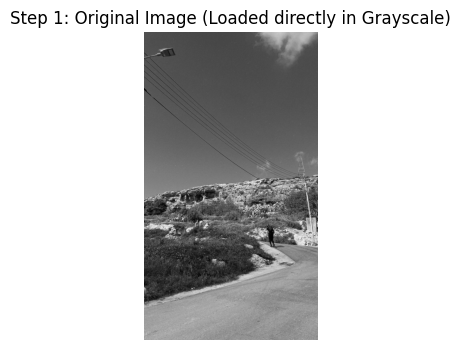

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image directly in grayscale in a single line
image_path = 'test_image.jpg'
gray_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if gray_image is None:
    print("Error: Could not load image. Check the file path.")
else:
    plt.figure(figsize=(6, 4))
    plt.imshow(gray_image, cmap='gray')
    plt.title("Step 1: Original Image (Loaded directly in Grayscale)")
    plt.axis('off')
    plt.show()

Step 2: The Bimodal Assumption and Histogram Analysis

Before applying Otsu's method, we need to understand how it makes its decision. Otsu's algorithm does not look at the image as a 2D spatial grid. instead, it looks at the histogram of pixel intensities.

The algorithm assumes that the image contains two main classes of pixels: the foreground and the background. Ideally, this creates a graph with two distinct mountains or peaks, separated by a deep valley.

To find the perfect cut-off point, Otsu's method iterates through all possible threshold values (from 0 to 255). For each value, it calculates the within-class variance. The optimal threshold is the one that minimizes this variance, meaning it ensures the pixels inside the "background" group are as similar to each other as possible, and the same goes for the "foreground" group.

Let's plot the histogram of our loaded image to see if it respects this bimodal assumption!

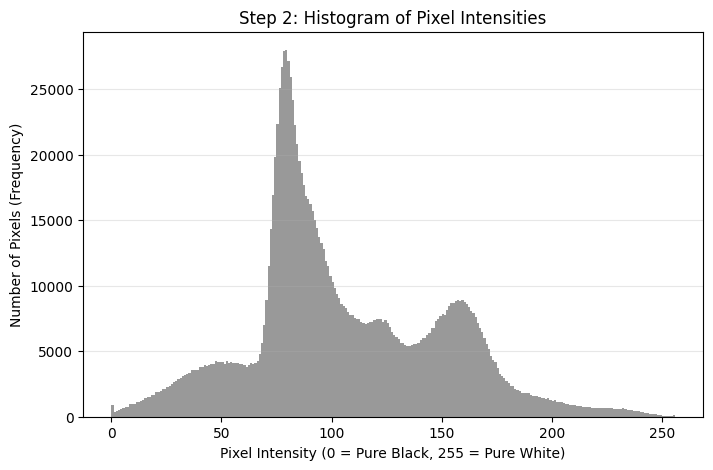

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten the 2D image matrix into a 1D list
# Ensure gray_image is a numpy array to avoid attribute errors
pixels = np.asarray(gray_image).ravel()
# Create and plot the histogram
plt.figure(figsize=(8, 5))
# Use 256 bins for the 256 possible intensity values (0 to 255)
plt.hist(pixels, bins=256, range=(0, 256), color='gray', alpha=0.8)
plt.title("Step 2: Histogram of Pixel Intensities")
plt.xlabel("Pixel Intensity (0 = Pure Black, 255 = Pure White)")
plt.ylabel("Number of Pixels (Frequency)")
plt.grid(axis='y', alpha=0.3)
# Display the graph
plt.show()

Step 3: Global Otsu's Thresholding and its Failure Case

Now that we understand the bimodal assumption, let's apply Otsu's method. OpenCV makes this incredibly easy: we use the "cv2.threshold" function and pass the "cv2.THRESH_OTSU" flag. The algorithm will automatically find the valley in our histogram, calculate the optimal threshold, and binarize the image.

However, we must also understand the limitations of this global approach. Otsu calculates a single threshold for the entire image. If our image has uneven lighting or a shadow cast across it, the bimodal assumption breaks down globally. The dark background in the shadow might be darker than the bright foreground in the well-lit area!

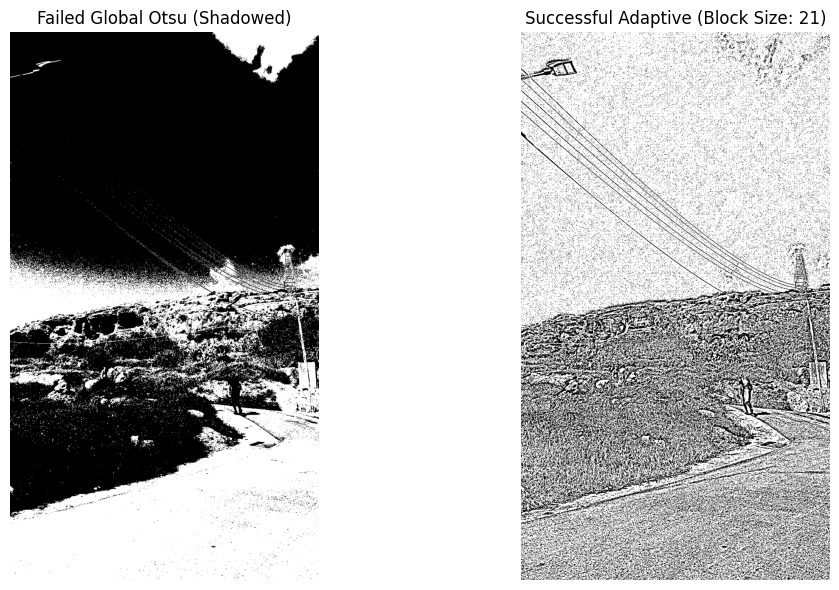

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Parameters for adaptive thresholding
block_size = 21
C_value = 5

# Apply Gaussian adaptive thresholding
# (Note: ensure that gray_image and otsu_result are defined beforehand)
adaptive_result = cv2.adaptiveThreshold(
    gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY, block_size, C_value
)

# Create the figure (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# First subplot: index [0]
axes[0].imshow(otsu_result, cmap='gray')
axes[0].set_title("Failed Global Otsu (Shadowed)")
axes[0].axis('off')

# Second subplot: index [1]
axes[1].imshow(adaptive_result, cmap='gray')
axes[1].set_title(f"Successful Adaptive (Block Size: {block_size})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Step 4: Adaptive Thresholding

As we observed in the previous step, global thresholding techniques like Otsu's method apply a single threshold value to every pixel in the image. This fails when the image has inhomogeneous lighting, such as a strong illumination gradient or shadows.

To overcome this, we use Adaptive Thresholding. Instead of one global decision, this method changes the threshold dynamically over different regions of the image. It calculates a local threshold for each pixel based on its immediate neighborhood.

We will use the Gaussian method, which calculates a weighted average of the neighborhood intensities, giving more importance to pixels closer to the center. This approach is far more dependable for real-world documents with uneven lighting.

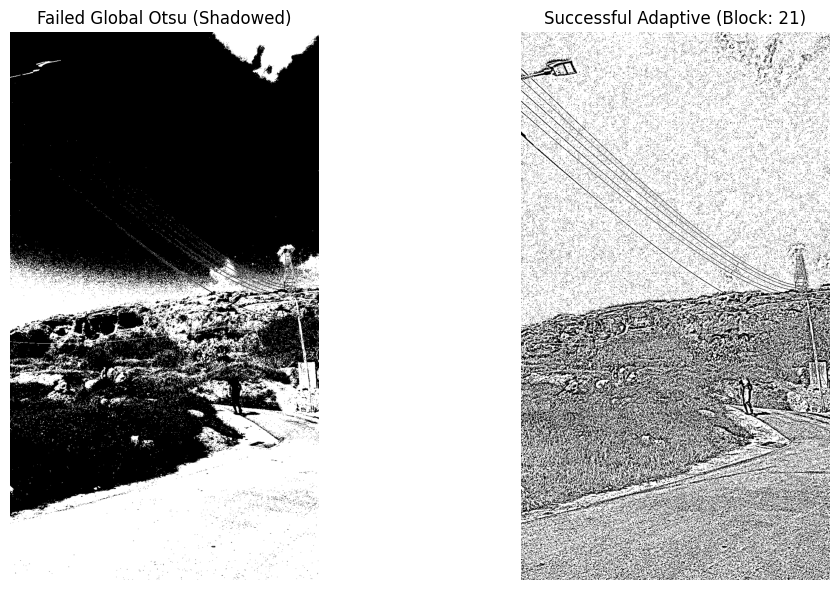

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Define the two key parameters:
# 1. block_size: The size of the local neighborhood (must be an odd number)
# 2. C: A constant subtracted from the local mean to fine-tune the threshold
block_size = 21
C_value = 5

# Apply Gaussian Adaptive Thresholding
# (Assumes gray_image is already defined in previous cells)
adaptive_result = cv2.adaptiveThreshold(
    gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY, block_size, C_value
)

# Comparison display: Failed Global vs. Successful Adaptive
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left subplot: The failed result from Otsu (Global)
axes[0].imshow(otsu_result, cmap='gray')
axes[0].set_title("Failed Global Otsu (Shadowed)")
axes[0].axis('off')

# Right subplot: The successful result from Adaptive
axes[1].imshow(adaptive_result, cmap='gray')
axes[1].set_title(f"Successful Adaptive (Block: {block_size})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Conclusion

In this walkthrough, we have explored the critical transition from global to local binarization techniques. We began with Otsu's Method, a robust algorithm for automatic thresholding that works by maximizing the between-class variance. While highly effective for images with a clear bimodal histogram, we demonstrated its primary limitation: it fails when faced with non-uniform illumination or strong shadows.

To address these challenges, we implemented Adaptive Thresholding. By calculating thresholds dynamically for small local regions rather than the entire image, this method proves far more dependable for processing real-world documents and unevenly lit scenes. Understanding how to tune parameters like the block_size and the constant C is essential for any computer vision pipeline aiming for high precision in complex environments.